In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
print('All libraries imported')

All libraries imported


In [5]:
df = pd.read_csv('advertising.csv')
print(f'Shape: {df.shape}')

Shape: (200, 5)


In [6]:
df.head(10)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


In [7]:
df.dtypes

Unnamed: 0      int64
TV            float64
Radio         float64
Newspaper     float64
Sales         float64
dtype: object

In [8]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [9]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


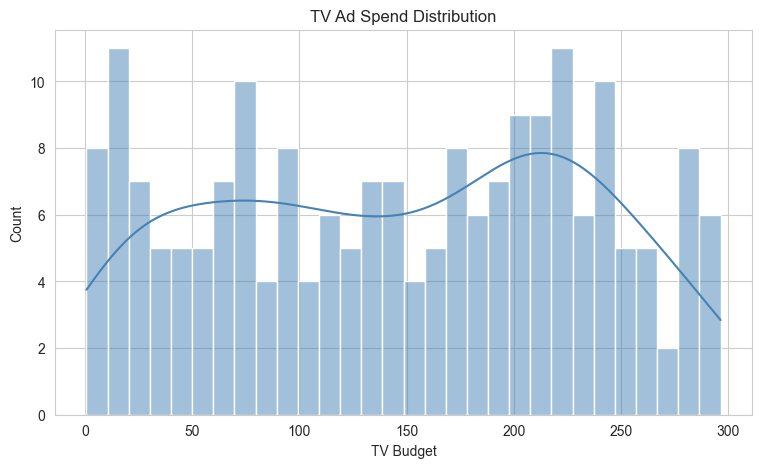

In [10]:
sns.histplot(df['TV'], kde=True, color='steelblue', bins=30)
plt.title('TV Ad Spend Distribution')
plt.xlabel('TV Budget')
plt.show()

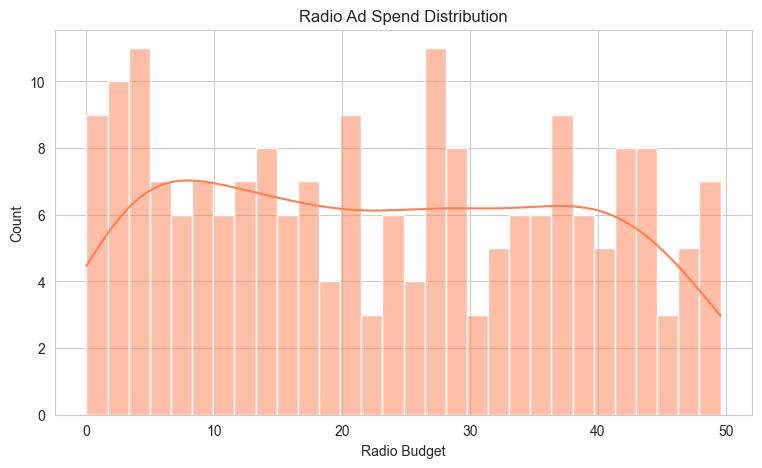

In [11]:
sns.histplot(df['Radio'], kde=True, color='coral', bins=30)
plt.title('Radio Ad Spend Distribution')
plt.xlabel('Radio Budget')
plt.show()

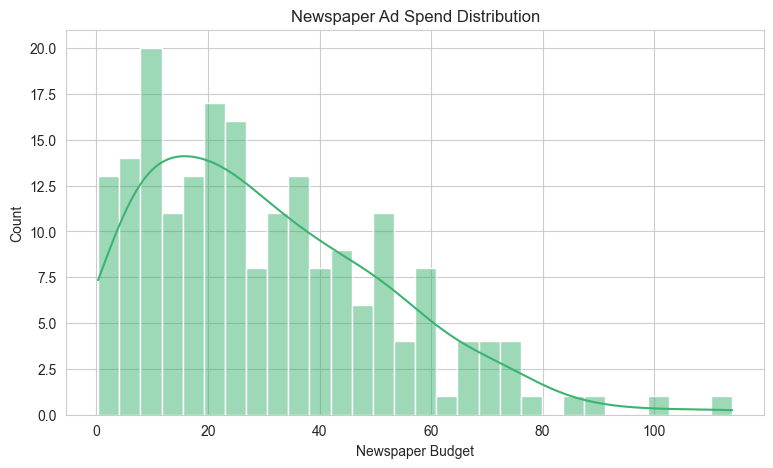

In [12]:
sns.histplot(df['Newspaper'], kde=True, color='mediumseagreen', bins=30)
plt.title('Newspaper Ad Spend Distribution')
plt.xlabel('Newspaper Budget')
plt.show()

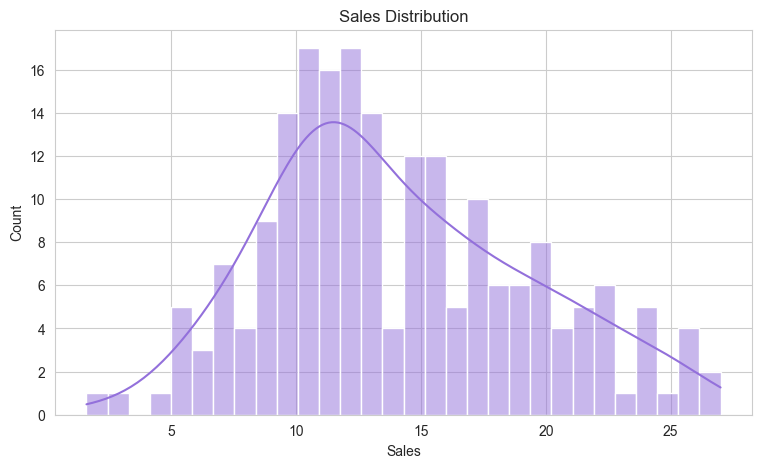

In [13]:
sns.histplot(df['Sales'], kde=True, color='mediumpurple', bins=30)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.show()

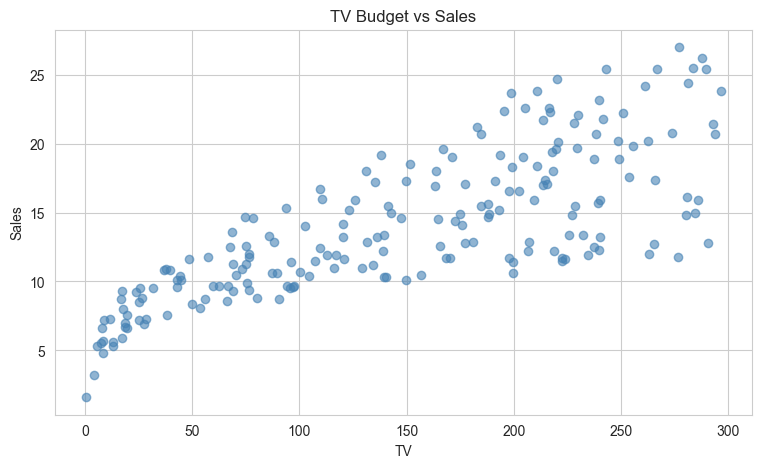

In [14]:
plt.scatter(df['TV'], df['Sales'], alpha=0.6, color='steelblue')
plt.title('TV Budget vs Sales')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.show()

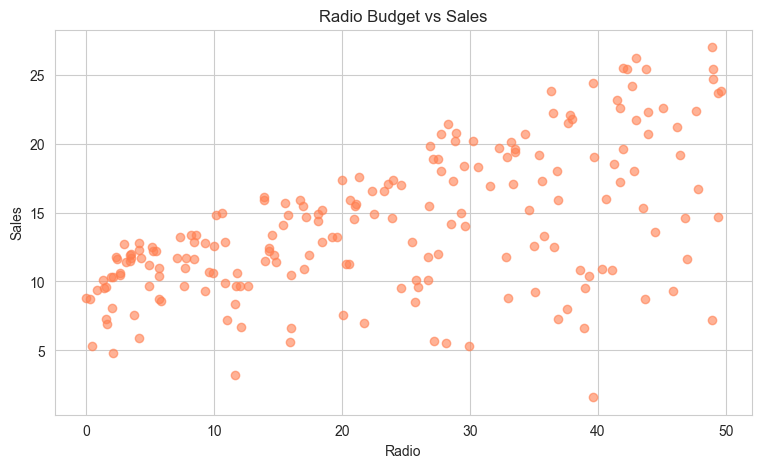

In [15]:
plt.scatter(df['Radio'], df['Sales'], alpha=0.6, color='coral')
plt.title('Radio Budget vs Sales')
plt.xlabel('Radio')
plt.ylabel('Sales')
plt.show()

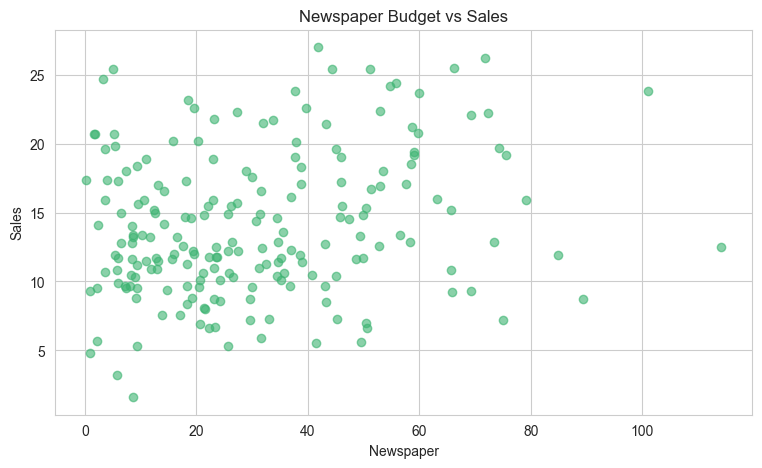

In [16]:
plt.scatter(df['Newspaper'], df['Sales'], alpha=0.6, color='mediumseagreen')
plt.title('Newspaper Budget vs Sales')
plt.xlabel('Newspaper')
plt.ylabel('Sales')
plt.show()

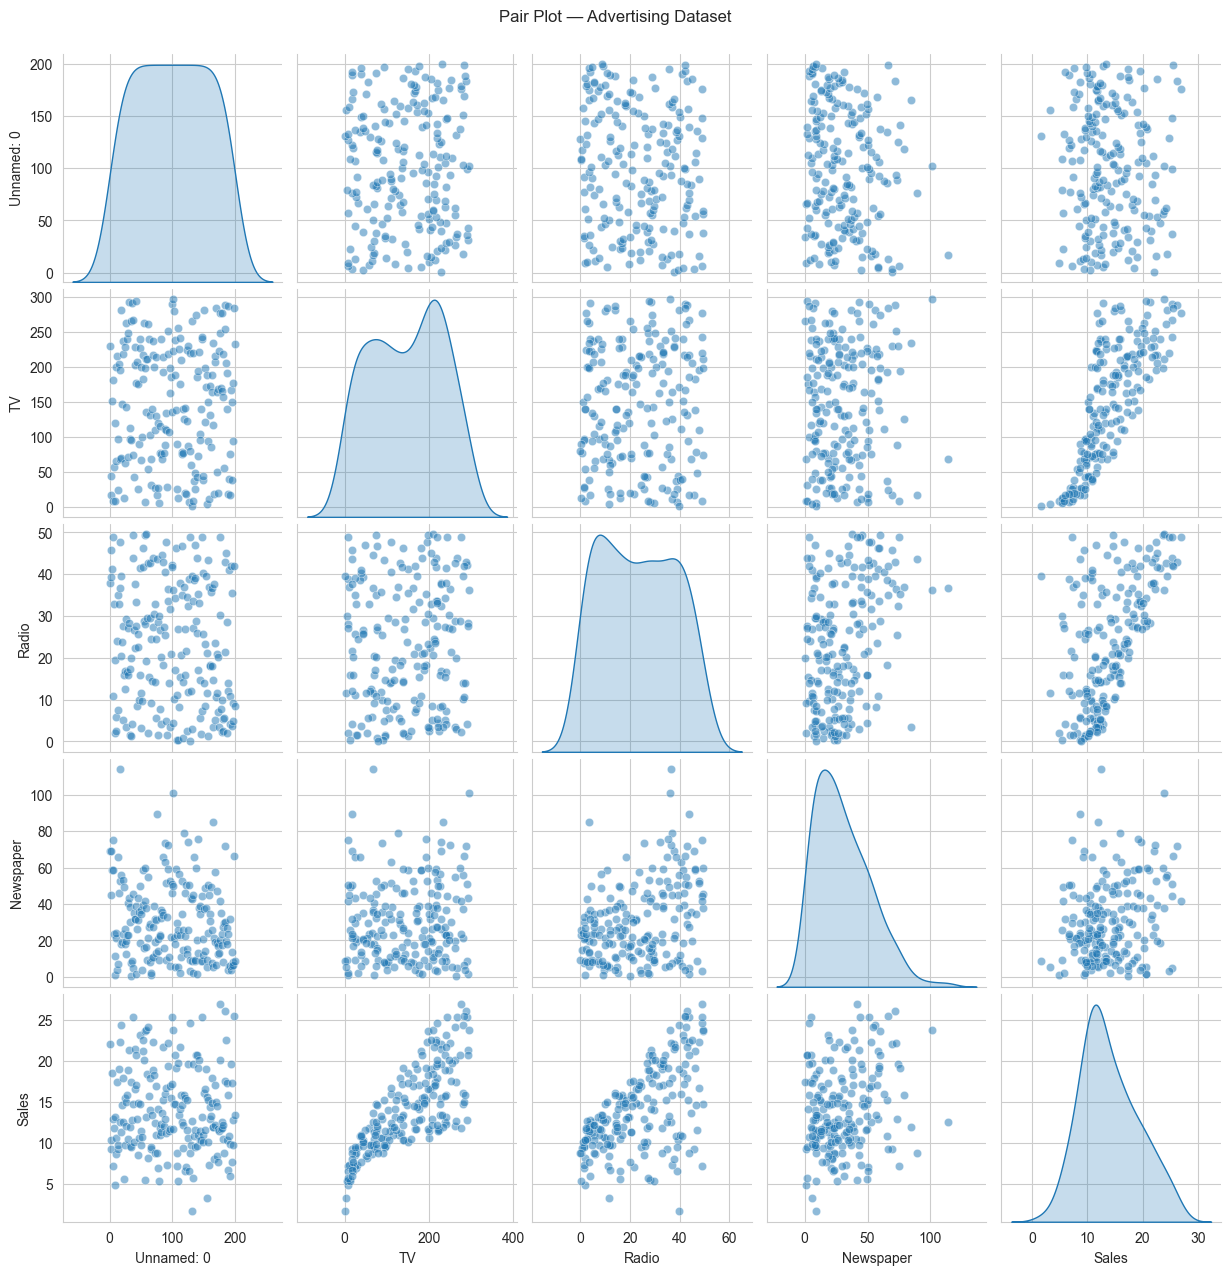

In [17]:
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pair Plot — Advertising Dataset', y=1.02)
plt.show()

In [18]:
corr = df.corr()
corr

,Unnamed: 0,TV,Radio,Newspaper,Sales
Unnamed: 0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
TV,0.017715,1.000000,0.054809,0.056648,0.782224
Radio,-0.110680,0.054809,1.000000,0.354104,0.576223
Newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
Sales,-0.051616,0.782224,0.576223,0.228299,1.000000


In [19]:
corr['Sales'].sort_values(ascending=False)

Sales         1.000000
TV            0.782224
Radio         0.576223
Newspaper     0.228299
Unnamed: 0   -0.051616
Name: Sales, dtype: float64

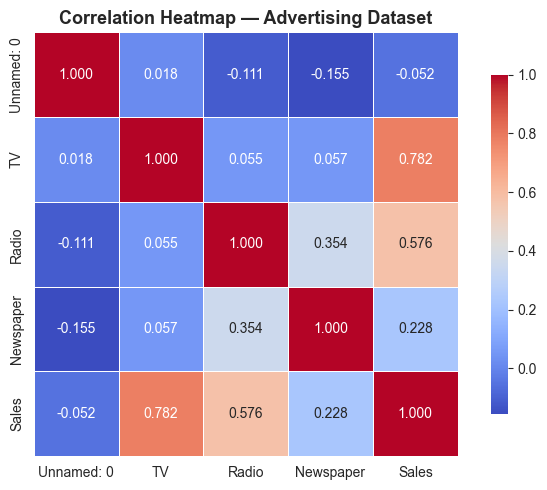

In [20]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Advertising Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
radio_news_corr = df['Radio'].corr(df['Newspaper'])
print(f'Correlation between Radio and Newspaper: {radio_news_corr:.4f}')

if abs(radio_news_corr) > 0.5:
    print('⚠️  Moderate-to-high correlation detected — possible multicollinearity!')
else:
    print('Low correlation between Radio and Newspaper.')

Correlation between Radio and Newspaper: 0.3541
Low correlation between Radio and Newspaper.


In [23]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']
print('Features:', list(X.columns))
print('Target  : Sales')

Features: ['TV', 'Radio', 'Newspaper']
Target  : Sales


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 160 | Test size: 40


In [25]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
print('Baseline model trained!')

Baseline model trained!


In [26]:
baseline_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': baseline_model.coef_
})
print(f'Intercept: {baseline_model.intercept_:.4f}')
baseline_coef

Intercept: 2.9791


,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


In [27]:
y_pred_baseline = baseline_model.predict(X_test)
y_pred_baseline[:5]

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326])

In [30]:
mae_b  = mean_absolute_error(y_test, y_pred_baseline)
rmse_b = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_b   = r2_score(y_test, y_pred_baseline)

print('Baseline Model (TV + Radio + Newspaper) ')
print(f'  MAE  : {mae_b:.4f}')
print(f'  RMSE : {rmse_b:.4f}')
print(f'  R²   : {r2_b:.4f}')

Baseline Model (TV + Radio + Newspaper) 
  MAE  : 1.4608
  RMSE : 1.7816
  R²   : 0.8994


In [31]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]
vif_data

,Feature,VIF
0,TV,2.486772
1,Radio,3.285462
2,Newspaper,3.055245


In [32]:
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
vif_data

,Feature,VIF
0,Radio,3.285462
1,Newspaper,3.055245
2,TV,2.486772


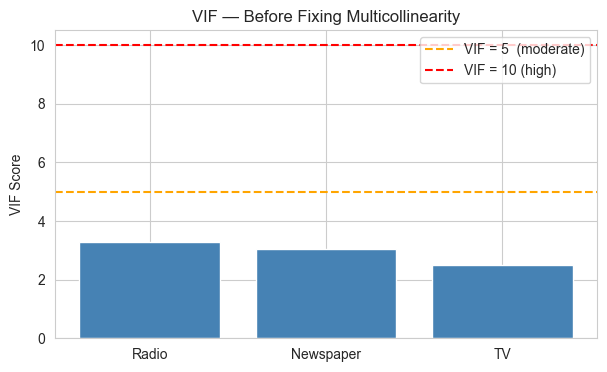

In [33]:
colors = ['red' if v > 5 else 'steelblue' for v in vif_data['VIF']]
plt.figure(figsize=(7, 4))
plt.bar(vif_data['Feature'], vif_data['VIF'], color=colors, edgecolor='white')
plt.axhline(y=5,  color='orange', linestyle='--', label='VIF = 5  (moderate)')
plt.axhline(y=10, color='red',    linestyle='--', label='VIF = 10 (high)')
plt.title('VIF — Before Fixing Multicollinearity')
plt.ylabel('VIF Score')
plt.legend()
plt.show()

In [34]:
high_vif_features = vif_data[vif_data['VIF'] > 5]
print('Features with VIF > 5 (multicollinearity concern):')
print(high_vif_features)

Features with VIF > 5 (multicollinearity concern):
Empty DataFrame
Columns: [Feature, VIF]
Index: []


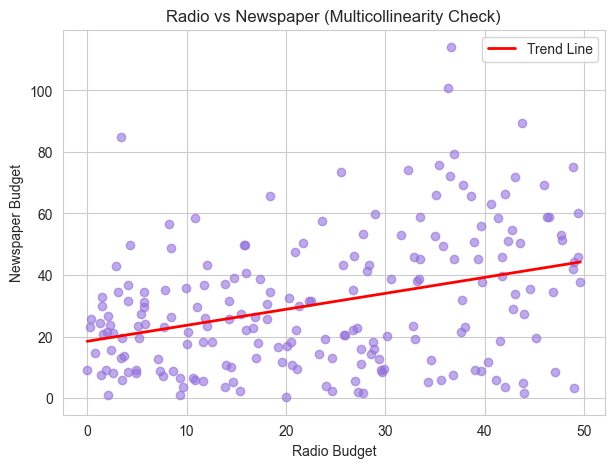

In [35]:
plt.figure(figsize=(7, 5))
plt.scatter(df['Radio'], df['Newspaper'], alpha=0.6, color='mediumpurple')
plt.title('Radio vs Newspaper (Multicollinearity Check)')
plt.xlabel('Radio Budget')
plt.ylabel('Newspaper Budget')

# Add regression line
m, b = np.polyfit(df['Radio'], df['Newspaper'], 1)
x_line = np.linspace(df['Radio'].min(), df['Radio'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=2, label='Trend Line')
plt.legend()
plt.show()

In [36]:
print('Baseline Coefficients (with all features including Newspaper):')
for feat, coef in zip(X.columns, baseline_model.coef_):
    print(f'  {feat:12s}: {coef:.6f}')

Baseline Coefficients (with all features including Newspaper):
  TV          : 0.044730
  Radio       : 0.189195
  Newspaper   : 0.002761


In [37]:
newspaper_coef = baseline_coef[baseline_coef['Feature'] == 'Newspaper']['Coefficient'].values[0]
print(f'Newspaper coefficient: {newspaper_coef:.6f}')
print('Near-zero or sign-flipped coefficient suggests multicollinearity')

Newspaper coefficient: 0.002761
Near-zero or sign-flipped coefficient suggests multicollinearity


In [38]:
print('Correlation with Sales:')
print(corr['Sales'][['TV', 'Radio', 'Newspaper']])

Correlation with Sales:
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


In [39]:
X_fixed = df[['TV', 'Radio']]
print('Features after removal:', list(X_fixed.columns))

Features after removal: ['TV', 'Radio']


In [40]:
vif_fixed = pd.DataFrame()
vif_fixed['Feature'] = X_fixed.columns
vif_fixed['VIF'] = [variance_inflation_factor(X_fixed.values, i)
                    for i in range(X_fixed.shape[1])]
vif_fixed

,Feature,VIF
0,TV,2.238085
1,Radio,2.238085


In [41]:
print('VIF BEFORE (all features):')
print(vif_data[['Feature', 'VIF']].to_string(index=False))
print()
print('VIF AFTER (Newspaper removed):')
print(vif_fixed.to_string(index=False))

VIF BEFORE (all features):
  Feature      VIF
    Radio 3.285462
Newspaper 3.055245
       TV 2.486772

VIF AFTER (Newspaper removed):
Feature      VIF
     TV 2.238085
  Radio 2.238085


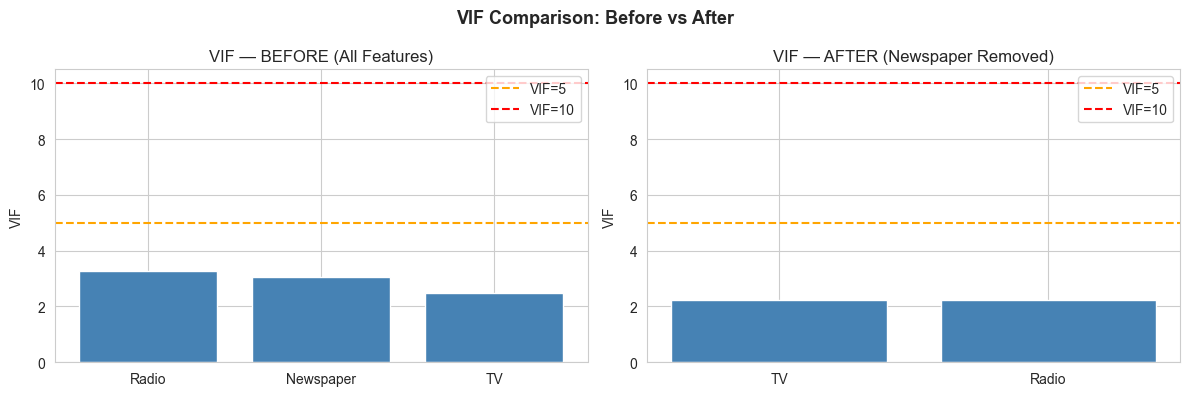

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
colors_b = ['red' if v > 5 else 'steelblue' for v in vif_data['VIF']]
axes[0].bar(vif_data['Feature'], vif_data['VIF'], color=colors_b, edgecolor='white')
axes[0].axhline(5, color='orange', linestyle='--', label='VIF=5')
axes[0].axhline(10, color='red', linestyle='--', label='VIF=10')
axes[0].set_title('VIF — BEFORE (All Features)')
axes[0].set_ylabel('VIF')
axes[0].legend()

# After
axes[1].bar(vif_fixed['Feature'], vif_fixed['VIF'], color='steelblue', edgecolor='white')
axes[1].axhline(5, color='orange', linestyle='--', label='VIF=5')
axes[1].axhline(10, color='red', linestyle='--', label='VIF=10')
axes[1].set_title('VIF — AFTER (Newspaper Removed)')
axes[1].set_ylabel('VIF')
axes[1].legend()

plt.suptitle('VIF Comparison: Before vs After', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fixed, y, test_size=0.2, random_state=42)
print(f'Train: {X_train_f.shape[0]} | Test: {X_test_f.shape[0]}')

Train: 160 | Test: 40


In [45]:
fixed_model = LinearRegression()
fixed_model.fit(X_train_f, y_train_f)
print('Fixed model trained')

Fixed model trained


In [46]:
fixed_coef = pd.DataFrame({
    'Feature': X_fixed.columns,
    'Coefficient': fixed_model.coef_
})
print(f'Intercept: {fixed_model.intercept_:.4f}')
fixed_coef

Intercept: 3.0283


,Feature,Coefficient
0,TV,0.044728
1,Radio,0.190667


In [47]:
y_pred_fixed = fixed_model.predict(X_test_f)
y_pred_fixed[:5]

array([16.35747252, 20.86299397, 21.52505848, 10.58719845, 22.22459614])

In [48]:
mae_f  = mean_absolute_error(y_test_f, y_pred_fixed)
rmse_f = np.sqrt(mean_squared_error(y_test_f, y_pred_fixed))
r2_f   = r2_score(y_test_f, y_pred_fixed)

print('=== Fixed Model (TV + Radio only) ===')
print(f'  MAE  : {mae_f:.4f}')
print(f'  RMSE : {rmse_f:.4f}')
print(f'  R²   : {r2_f:.4f}')

=== Fixed Model (TV + Radio only) ===
  MAE  : 1.4443
  RMSE : 1.7714
  R²   : 0.9006


In [49]:
coef_compare = pd.DataFrame({
    'Feature': ['TV', 'Radio', 'Newspaper'],
    'Before (Baseline)': list(baseline_model.coef_),
    'After (Fixed)': [fixed_model.coef_[0], fixed_model.coef_[1], np.nan]
})
coef_compare

,Feature,Before (Baseline),After (Fixed)
0,TV,0.044730,0.044728
1,Radio,0.189195,0.190667
2,Newspaper,0.002761,NaN


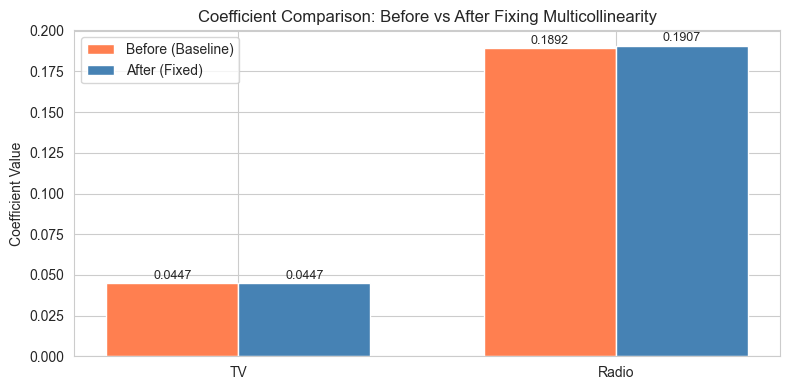

In [50]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)  # TV and Radio only
width = 0.35

bars1 = ax.bar(x - width/2, baseline_model.coef_[:2], width,
               label='Before (Baseline)', color='coral', edgecolor='white')
bars2 = ax.bar(x + width/2, fixed_model.coef_, width,
               label='After (Fixed)', color='steelblue', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(['TV', 'Radio'])
ax.set_title('Coefficient Comparison: Before vs After Fixing Multicollinearity')
ax.set_ylabel('Coefficient Value')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

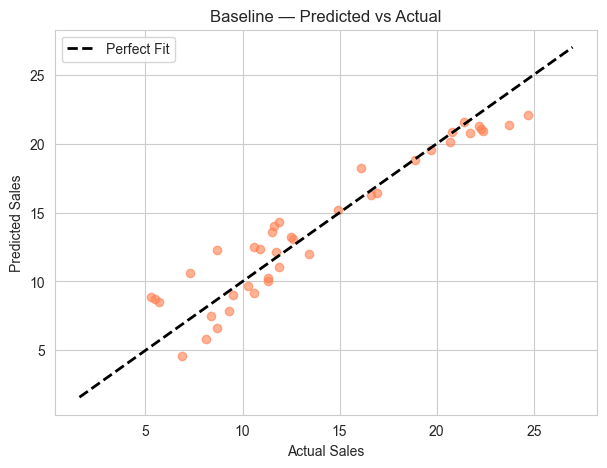

In [51]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_baseline, alpha=0.6, color='coral')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Fit')
plt.title('Baseline — Predicted vs Actual')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.legend()
plt.show()

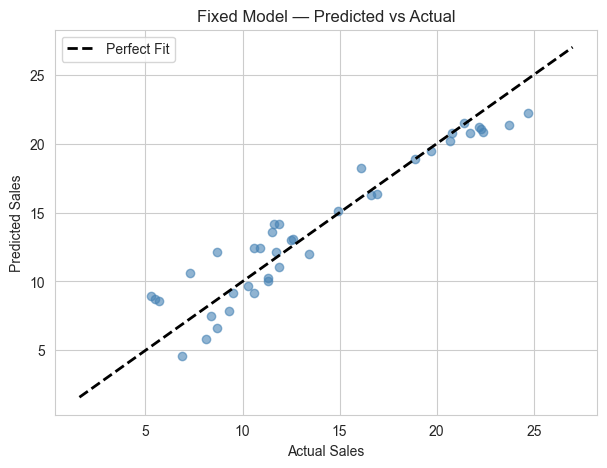

In [52]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_f, y_pred_fixed, alpha=0.6, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Fit')
plt.title('Fixed Model — Predicted vs Actual')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.legend()
plt.show()

In [53]:
residuals_b = y_test - y_pred_baseline
residuals_f = y_test_f - y_pred_fixed
print(f'Baseline residual mean : {residuals_b.mean():.4f}')
print(f'Fixed    residual mean : {residuals_f.mean():.4f}')

Baseline residual mean : -0.0975
Fixed    residual mean : -0.0920


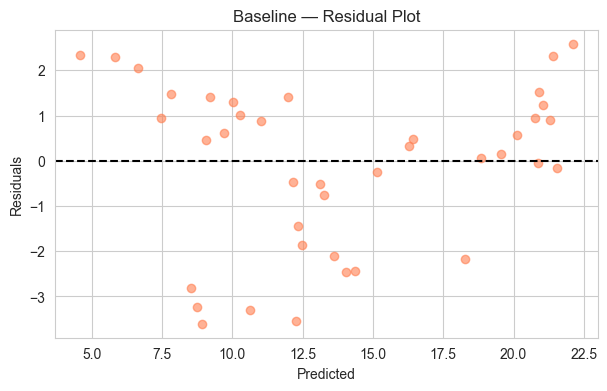

In [54]:
plt.figure(figsize=(7, 4))
plt.scatter(y_pred_baseline, residuals_b, alpha=0.6, color='coral')
plt.axhline(0, color='black', linestyle='--')
plt.title('Baseline — Residual Plot')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.show()

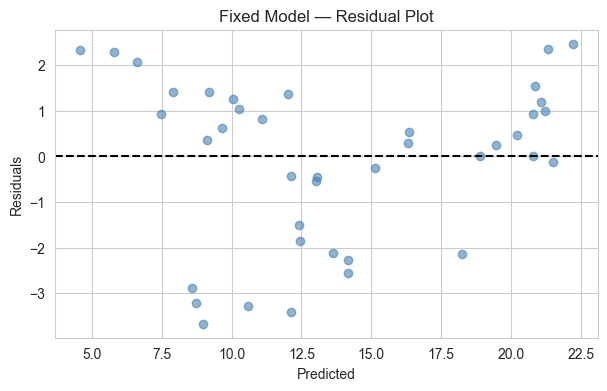

In [55]:
plt.figure(figsize=(7, 4))
plt.scatter(y_pred_fixed, residuals_f, alpha=0.6, color='steelblue')
plt.axhline(0, color='black', linestyle='--')
plt.title('Fixed Model — Residual Plot')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.show()

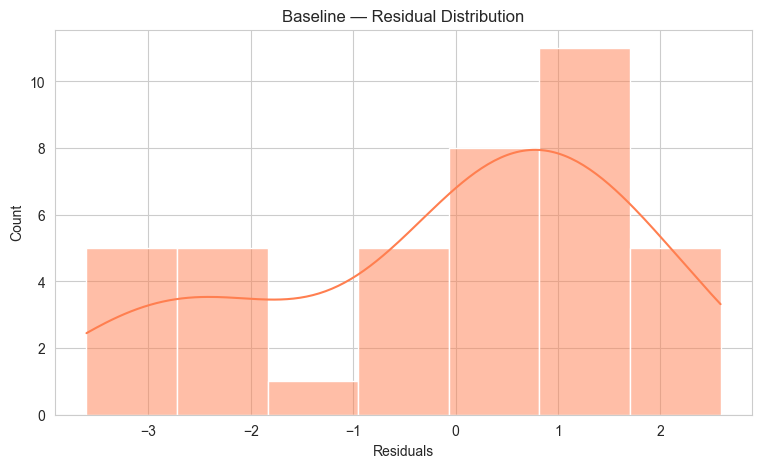

In [56]:
sns.histplot(residuals_b, kde=True, color='coral')
plt.title('Baseline — Residual Distribution')
plt.xlabel('Residuals')
plt.show()

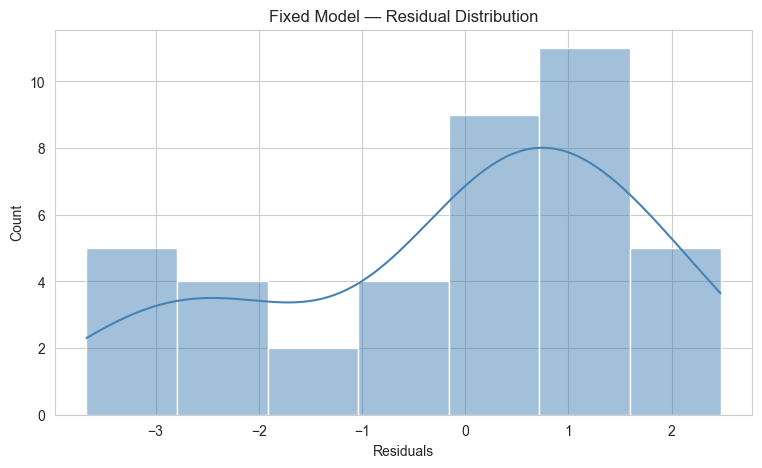

In [57]:
sns.histplot(residuals_f, kde=True, color='steelblue')
plt.title('Fixed Model — Residual Distribution')
plt.xlabel('Residuals')
plt.show()

In [58]:
comparison = pd.DataFrame({
    'Model':    ['Baseline (TV+Radio+Newspaper)', 'Fixed (TV+Radio)'],
    'Features': [3, 2],
    'MAE':      [round(mae_b, 4),  round(mae_f, 4)],
    'RMSE':     [round(rmse_b, 4), round(rmse_f, 4)],
    'R²':       [round(r2_b, 4),   round(r2_f, 4)]
})
comparison

,Model,Features,MAE,RMSE,R²
0,Baseline (TV+Radio+Newspaper),3,1.4608,1.7816,0.8994
1,Fixed (TV+Radio),2,1.4443,1.7714,0.9006


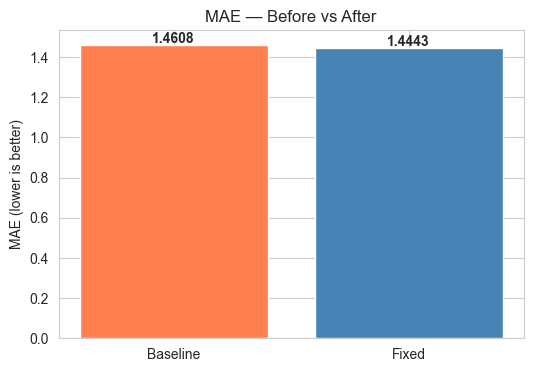

In [59]:
plt.figure(figsize=(6, 4))
plt.bar(['Baseline', 'Fixed'], [mae_b, mae_f], color=['coral', 'steelblue'], edgecolor='white')
plt.title('MAE — Before vs After')
plt.ylabel('MAE (lower is better)')
for i, v in enumerate([mae_b, mae_f]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.show()

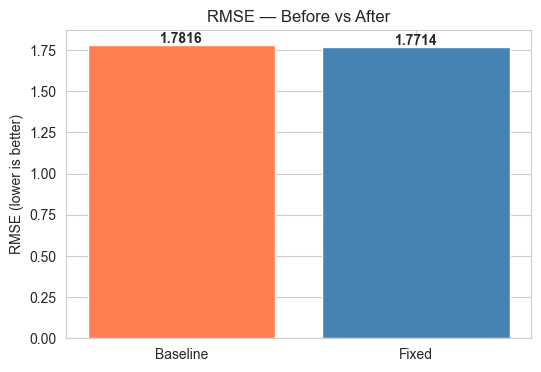

In [60]:
plt.figure(figsize=(6, 4))
plt.bar(['Baseline', 'Fixed'], [rmse_b, rmse_f], color=['coral', 'steelblue'], edgecolor='white')
plt.title('RMSE — Before vs After')
plt.ylabel('RMSE (lower is better)')
for i, v in enumerate([rmse_b, rmse_f]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.show()

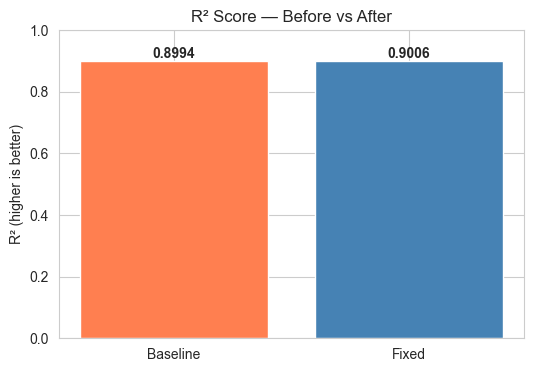

In [61]:
plt.figure(figsize=(6, 4))
plt.bar(['Baseline', 'Fixed'], [r2_b, r2_f], color=['coral', 'steelblue'], edgecolor='white')
plt.title('R² Score — Before vs After')
plt.ylabel('R² (higher is better)')
plt.ylim(0, 1)
for i, v in enumerate([r2_b, r2_f]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.show()

In [62]:
print('Baseline model (with Newspaper):')
for feat, coef in zip(['TV', 'Radio', 'Newspaper'], baseline_model.coef_):
    print(f'  {feat:12s}: {coef:.6f}')

print()
print('Fixed model (without Newspaper):')
for feat, coef in zip(['TV', 'Radio'], fixed_model.coef_):
    print(f'  {feat:12s}: {coef:.6f}')

Baseline model (with Newspaper):
  TV          : 0.044730
  Radio       : 0.189195
  Newspaper   : 0.002761

Fixed model (without Newspaper):
  TV          : 0.044728
  Radio       : 0.190667


In [63]:
print('Performance Improvement')
print(f'MAE  improvement : {mae_b - mae_f:+.4f}  (negative = fixed is better)')
print(f'RMSE improvement : {rmse_b - rmse_f:+.4f}  (negative = fixed is better)')
print(f'R²   improvement : {r2_f - r2_b:+.4f}  (positive = fixed is better)')

Performance Improvement
MAE  improvement : +0.0165  (negative = fixed is better)
RMSE improvement : +0.0102  (negative = fixed is better)
R²   improvement : +0.0011  (positive = fixed is better)
